# Lecture 1 live demonstration

## Can the data show whether Pakistan's Big Three are losing dominance?

For each code cell, ask students to predict the output before running it. The prepared files come from `prepare_data.py`. Lecture 2 will examine that preparation process.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_DATA = Path("courses/data-analysis-and-visualization/lectures/lecture-01/data")
DATA_DIR = next((path for path in (Path("data"), REPO_DATA) if (path / "passenger_cars_long.csv").exists()), Path("data"))
sales = pd.read_csv(DATA_DIR / "passenger_cars_long.csv", parse_dates=["date"])
annual_brand = pd.read_csv(DATA_DIR / "annual_brand_sales.csv")
summary = pd.read_csv(DATA_DIR / "annual_market_summary.csv")

## 1. Inspect before calculating

Ask students what one row represents and which columns define the source of a value.

In [3]:
sales.head()

,fiscal_year,date,manufacturer,model_group,measure,units,source_sheet,source_row
0,2007-08,2007-07-01,Honda,Honda Civic,Production,554,2007-08,9
1,2007-08,2007-08-01,Honda,Honda Civic,Production,533,2007-08,9
2,2007-08,2007-09-01,Honda,Honda Civic,Production,405,2007-08,9
3,2007-08,2007-10-01,Honda,Honda Civic,Production,662,2007-08,9
4,2007-08,2007-11-01,Honda,Honda Civic,Production,423,2007-08,9


In [4]:
sales.shape, sales['fiscal_year'].nunique(), sales['fiscal_year'].iloc[[0, -1]].tolist()

((4560, 8), 19, ['2007-08', '2025-26'])

In [5]:
sales.isna().sum()

fiscal_year     0
date            0
manufacturer    0
model_group     0
measure         0
units           0
source_sheet    0
source_row      0
dtype: int64

## 2. Annual recorded passenger car sales

Prediction prompt: Which fiscal year has the highest recorded total? Where do the sharpest changes occur?

In [6]:
summary[['fiscal_year', 'total_recorded_sales']]

,fiscal_year,total_recorded_sales
0,2007-08,164650
1,2008-09,82844
2,2009-10,123957
3,2010-11,127944
4,2011-12,157325
5,2012-13,118830
6,2013-14,118102
7,2014-15,151134
8,2015-16,181145
9,2016-17,185781


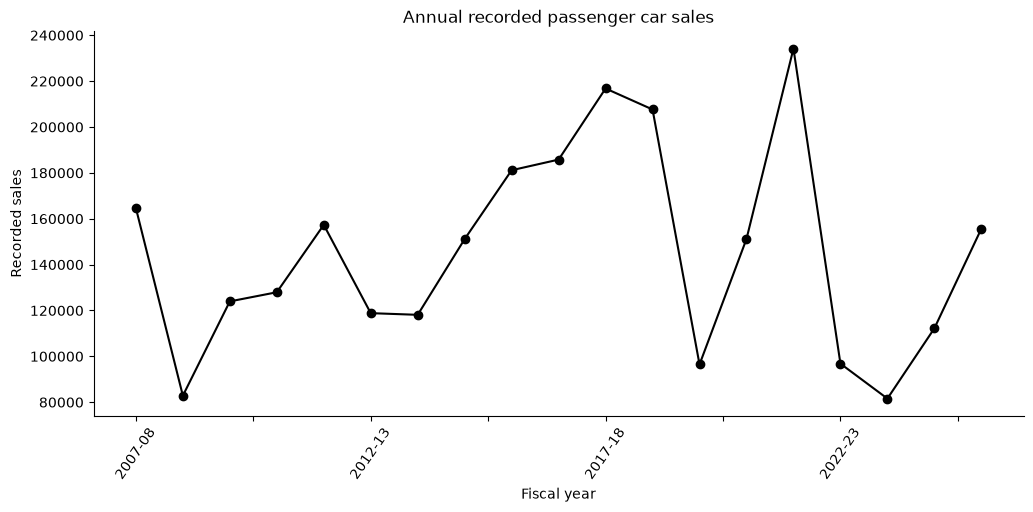

In [7]:
ax = summary.plot(
    x='fiscal_year',
    y='total_recorded_sales',
    color='black',
    marker='o',
    figsize=(12, 5),
    legend=False,
)
ax.set(title='Annual recorded passenger car sales', xlabel='Fiscal year', ylabel='Recorded sales')
ax.tick_params(axis='x', rotation=55)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

In [8]:
summary.assign(
    year_to_year_change=summary['total_recorded_sales'].pct_change()
)[['fiscal_year', 'total_recorded_sales', 'year_to_year_change']]

,fiscal_year,total_recorded_sales,year_to_year_change
0,2007-08,164650,NaN
1,2008-09,82844,-0.496848
2,2009-10,123957,0.496270
3,2010-11,127944,0.032164
4,2011-12,157325,0.229640
5,2012-13,118830,-0.244685
6,2013-14,118102,-0.006126
7,2014-15,151134,0.279690
8,2015-16,181145,0.198572
9,2016-17,185781,0.025593


The calculation describes when sales changed. It does not identify the cause.

## 3. Big Three recorded share

CR3 is the combined recorded share of Suzuki, Toyota, and Honda. Ask students to state the denominator before interpreting it.

In [9]:
summary[['fiscal_year', 'big_three_recorded_sales', 'big_three_recorded_share']].assign(
    big_three_recorded_share=lambda frame: frame['big_three_recorded_share'].map(lambda value: f'{value:.1%}')
)

,fiscal_year,big_three_recorded_sales,big_three_recorded_share
0,2007-08,150219,91.2%
1,2008-09,76588,92.4%
2,2009-10,118412,95.5%
3,2010-11,121937,95.3%
4,2011-12,153468,97.5%
5,2012-13,118759,99.9%
6,2013-14,117950,99.9%
7,2014-15,151084,100.0%
8,2015-16,181138,100.0%
9,2016-17,185780,100.0%


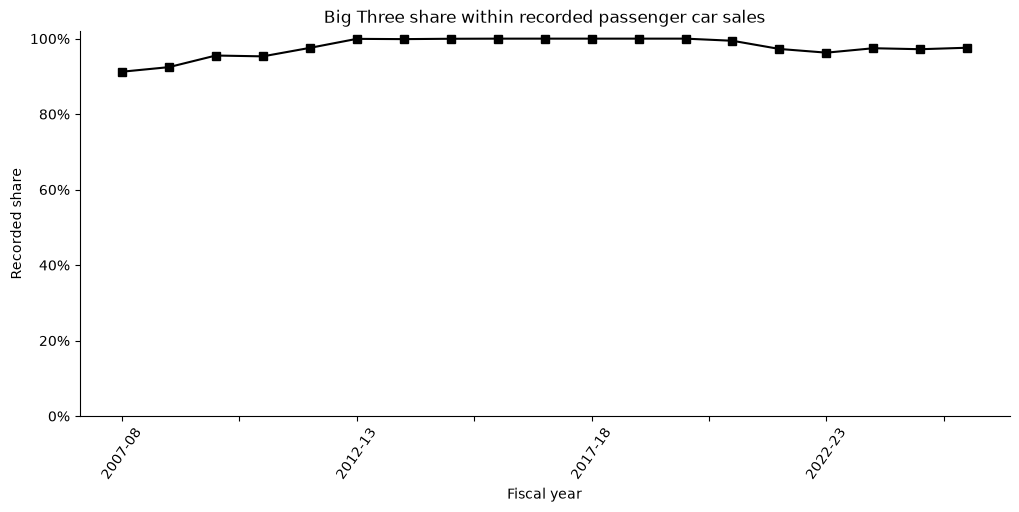

In [10]:
ax = summary.assign(share_percent=100 * summary['big_three_recorded_share']).plot(
    x='fiscal_year',
    y='share_percent',
    color='black',
    marker='s',
    figsize=(12, 5),
    legend=False,
)
ax.set(title='Big Three share within recorded passenger car sales', xlabel='Fiscal year', ylabel='Recorded share')
ax.set_ylim(0, 102)
ax.set_yticks([0, 20, 40, 60, 80, 100], labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax.tick_params(axis='x', rotation=55)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 4. The separately reported electric car category

The workbook begins showing a separate Honri-Ve row near the end of the period. A category's absence in earlier records does not prove that no electric cars existed in Pakistan.

In [11]:
summary.loc[
    summary['recorded_ev_sales'].gt(0),
    ['fiscal_year', 'recorded_ev_sales', 'total_recorded_sales', 'recorded_ev_share'],
].assign(
    recorded_ev_share=lambda frame: frame['recorded_ev_share'].map(lambda value: f'{value:.2%}')
)

,fiscal_year,recorded_ev_sales,total_recorded_sales,recorded_ev_share
17,2024-25,186.0,112203,0.17%
18,2025-26,343.0,155631,0.22%


## 5. Final interpretation

A defensible conclusion includes the finding, the represented population, and the main limitation.

**Model conclusion:** Within the PAMA passenger car records, Suzuki, Toyota, and Honda continue to account for nearly all recorded sales. The workbook may omit parts of the wider market, so it cannot establish their share of every new passenger car sold in Pakistan.